# MovieLens: course replication and timestamp analysis

Decision 618 | 2026-10-07 | English methods with Chinese explanations

## tl;dr

We reproduced the exact instructor random split and audited all 20 cached CV ranks. The rank-8 classroom refit has RMSE **0.9198**. A fresh 400-fit CV selects **rank 9**, with a small advantage over rank 8.

The rebuilt static ensemble has random-test RMSE **0.8990**; timestamps reduce it to **0.8940**. On a separate future holdout, timestamps reduce ensemble RMSE from **1.0303** to **1.0001**. Raw CF performs poorly in that future test, and we retain that result.

中文：老师的随机切分适合评分补全；按时间预测未来，需要另设时间验证。我们保留课堂基准，并单独验证时间特征，而不是把两套分数直接比较。时间戳记录评分录入时间，不能直接当作观影顺序。

This is an executed research companion. The code below reviews actual completed fits; optional refitting is explicit. It does not silently substitute cached output for a new model fit.

## Context & Methods

**Question.** For a known user, candidate movie and current rating-entry time, can course-based CF plus metadata and timestamps reduce held-out rating error? The target remains the explicit 1-5 rating. This is distinct from next-item ranking.

**Course anchors.** Lecture 2 PDF p.65 recommends recent-data holdouts for time dependence. Lecture 7 PDF pp.47 and 52 uses random 99/1 and training-only 20-fold CV. Lecture 7 pp.55-59 already proposes date/time in an ensemble. Lecture 6 motivates regularization. Page numbers are physical PDF positions; notebook cells are zero-based. Exact sources are in `sources/course_manifest.json`.

中文：老师并没有要求所有项目使用同一种比例。新增部分是可复跑的集成、timestamp 消融实验和时间评价；老师已经讲过 date/time 的特征想法。

### Key Assumptions

- The timestamp is known at prediction time; it represents a rating-entry time, not a verified viewing time. Calendar features use UTC, not inferred local time.
- The final model and history are frozen throughout the holdout; held-out interactions do not update features online. Equal-second history entries are excluded.
- Temporal boundaries are chosen using timestamps only. Hyperparameters use training/validation, never final-test labels. All unknown-ID cases remain in the test.
- Random stacking uses audited teacher OOF CF predictions. Its internal group validation is not fully nested CF refitting. Temporal stacking uses earlier-data fits for every calibration prediction, but common validation selects its hyperparameters retrospectively.
- User-level paired bootstrap intervals are conditional on this split/model procedure and do not establish a causal or business effect.
- Instructor R version/initialization are unknown. New fits use R 4.0.2 / softImpute 1.4-1 and explicit seeds. Numerical results need not match the saved notebook exactly.

### 1. Setup

The review run uses the local completed experiment. To retrain, first read `README.md`, then enable the optional pipeline cell. All paths remain relative to this project folder.

In [1]:
from pathlib import Path
import sys, json, os
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

candidates = [Path.cwd(), Path.cwd() / 'course_rebuild_20261007', Path.cwd().parent]
ROOT = next(p.resolve() for p in candidates if (p / 'code/prepare.py').exists())
sys.path.insert(0, str(ROOT / 'code'))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / 'runtime/mpl-cache'))
os.environ.setdefault('XDG_CACHE_HOME', str(ROOT / 'runtime/font-cache'))
import matplotlib.pyplot as plt
from prepare import load_ratings
from charts import (cv_chart, model_chart, time_chart, gap_chart, population_chart,
                    interval_chart, genre_chart, forecast_chart)
get_ipython().run_line_magic('matplotlib', 'inline')
pd.set_option('display.max_columns', 12)
pd.set_option('display.precision', 4)
manifest = json.loads((ROOT / 'sources/course_manifest.json').read_text())
assert manifest['unavailable'] == []
display(pd.DataFrame([{'Source files reviewed': len(manifest['files']),
                      'Course': manifest['course'], 'Retrieved': manifest['retrieved_date']}]))

,Source files reviewed,Course,Retrieved
0,39,4169,2026-10-07


### 2. Optional full model refit

Default is `False`: the 400 new fits have already been completed and logged. A full rerun needs R/softImpute and the original Canvas source cache. The compact package omits that cache, while the complete local directory retains it.

In [2]:
RETRAIN = False
if RETRAIN:
    import subprocess
    subprocess.run([sys.executable, str(ROOT / 'code/run_all.py'), '--fresh-cv'],
                   cwd=ROOT, check=True)
else:
    print('Reviewing completed experiment artifacts; all 400 fresh fits are checked below.')

Reviewing completed experiment artifacts; all 400 fresh fits are checked below.


## Data

### 3. Load and check the raw tables

No duplicated user-movie pair, missing value or out-of-range rating is removed silently. The source movies file contains 3,883 titles; only 3,706 receive a rating.

In [3]:
ratings = load_ratings()
ratings['row'] = np.arange(len(ratings))
assert len(ratings) == 1_000_209
assert not ratings.duplicated(['user', 'movie']).any()
assert not ratings.isna().any().any()
assert ratings.rating.between(1, 5).all()
display(pd.DataFrame([{'Ratings': len(ratings), 'Users': ratings.user.nunique(),
                      'Rated movies': ratings.movie.nunique(),
                      'Min rating': ratings.rating.min(), 'Max rating': ratings.rating.max()}]))
display(ratings.head(5))

,Ratings,Users,Rated movies,Min rating,Max rating
0,1000209,6040,3706,1,5


,user,movie,rating,timestamp,row
0,1,1193,5,978300760,0
1,1,661,3,978302109,1
2,1,914,3,978301968,2
3,1,3408,4,978300275,3
4,1,2355,5,978824291,4


### 4. Reconstruct the exact classroom split

Original source: ColFil_dist.ipynb cells 5-7. Legacy RandomState is essential. The rank is selected within the training partition, never from final-test ratings.

中文：99% 的 1,000,209 向下取整为 990,206，剩余为 10,003；它是按评分行随机抽样，不是按用户切分。

In [4]:
n = len(ratings)
rng = np.random.RandomState(144)
teacher_train = np.sort(rng.choice(np.arange(n), int(.99 * n), replace=False))
teacher_test = np.setdiff1d(np.arange(n), teacher_train)
teacher_folds = np.random.RandomState(144).randint(1, 21, size=len(teacher_train))
saved = np.load(ROOT / 'data/teacher_split.npz')
assert np.array_equal(teacher_train, saved['train'])
assert np.array_equal(teacher_test, saved['test'])
assert np.array_equal(teacher_folds, saved['cv_fold'])
assert teacher_test[:5].tolist() == [99, 238, 283, 363, 417]
display(pd.DataFrame([{'Train ratings': len(teacher_train), 'Test ratings': len(teacher_test),
                      'Train users': ratings.iloc[teacher_train].user.nunique(), 'Seed': 144}]))

,Train ratings,Test ratings,Train users,Seed
0,990206,10003,6040,144


### 5. Define strict time partitions

Boundary timestamps use only event time at the 80th/90th percentiles. Whole equal-timestamp groups remain together. Final CF refitting combines train and validation after selection.

In [5]:
timestamps = ratings.timestamp.to_numpy()
ordered_time = np.sort(timestamps)
cut_train = ordered_time[int(.8 * n)]
cut_test = ordered_time[int(.9 * n)]
temporal = {'train': np.flatnonzero(timestamps < cut_train),
            'validation': np.flatnonzero((timestamps >= cut_train) & (timestamps < cut_test)),
            'test': np.flatnonzero(timestamps >= cut_test)}
assert len(np.unique(np.concatenate(list(temporal.values())))) == n
assert timestamps[temporal['train']].max() < timestamps[temporal['validation']].min()
assert timestamps[temporal['validation']].max() < timestamps[temporal['test']].min()
time_info = json.loads((ROOT / 'results/temporal_split.json').read_text())
display(pd.DataFrame(time_info['partitions']))
latest = ratings.iloc[teacher_train].groupby('user').timestamp.max()
random_query = ratings.iloc[teacher_test]
future_fraction = (random_query.user.map(latest) > random_query.timestamp).mean()
display(Markdown(f'**{future_fraction:.2%}** of random-test ratings have a later same-user training rating.'))

,split,rows,first_utc,last_utc,users,movies
0,train,800164,2000-04-25T23:05:32+00:00,2000-12-02T14:51:59+00:00,5400,3662
1,validation,100024,2000-12-02T14:52:18+00:00,2000-12-29T23:42:47+00:00,1134,3305
2,test,100021,2000-12-29T23:43:34+00:00,2003-02-28T17:49:50+00:00,1209,3407


**98.85%** of random-test ratings have a later same-user training rating.

The random benchmark measures rating completion with nearly complete histories. Forecasting requires a different holdout. The two protocols contain different populations, so their RMSE difference is not a direct estimate of the effect of chronology.

中文：这里没有说随机切分本身错误。它回答的是另一种使用场景；预测未来时要控制信息的时间。

## Results

### 6. Cached CV audit and 400 fresh fits

The instructor cache was independently rescored for all 20 ranks. New CV uses the same rows/folds and R seeds `144 + 100 * fold + rank`. Both use lambda=0, maxit=1000 and clipped 1-5 predictions.

,Experiment,Rank,CV RMSE
0,"Instructor cache, independently scored",8,0.9196
1,Fresh 400 fits,9,0.9183


,rank,RMSE,MAE,OSR2
8,9,0.9183,0.7081,0.3242
7,8,0.9190,0.7093,0.3232
9,10,0.9199,0.7086,0.3218
6,7,0.9205,0.7114,0.3209


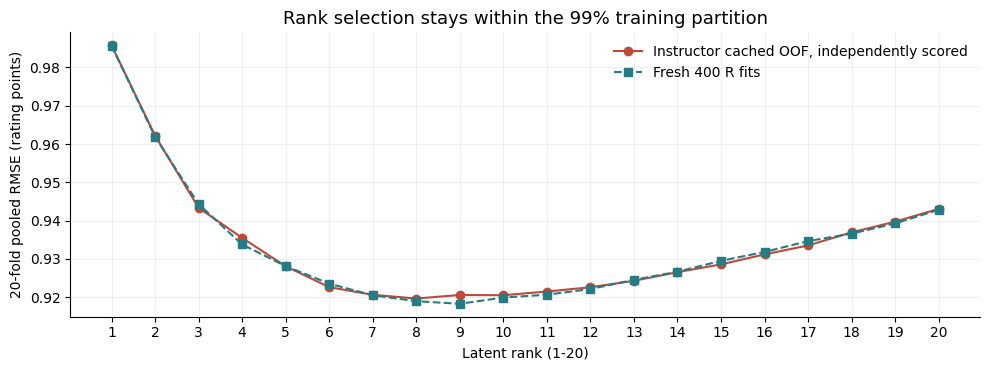

In [6]:
cache = pd.read_csv(ROOT / 'results/teacher_cv_recomputed.csv')
fresh = pd.read_csv(ROOT / 'results/fresh_cv_metrics.csv')
log = pd.read_csv(ROOT / 'results/fresh_cv_fit_log.csv')
assert len(log) == 400 and len(log[['fold', 'rank']].drop_duplicates()) == 400
assert log.warnings.fillna('').eq('').all()
display(pd.DataFrame([
    {'Experiment': 'Instructor cache, independently scored', 'Rank': 8,
     'CV RMSE': cache.loc[cache.archetypes == 8, 'RMSE'].iloc[0]},
    {'Experiment': 'Fresh 400 fits', 'Rank': int(fresh.loc[fresh.RMSE.idxmin(), 'rank']),
     'CV RMSE': fresh.RMSE.min()}]))
display(fresh.sort_values('RMSE').head(4))
fig = cv_chart()
display(fig)
plt.close(fig)

Fresh CV selects rank **9**, RMSE **0.918274**. The small gap around ranks 8-9 and the unknown instructor R initialization limit claims about a unique best rank. The faithful classroom comparison uses the original cache-selected rank 8; the fresh-selected final refit is saved separately.

中文：原缓存选 8，新实验选 9。流程已经完整复现，但数值和最优参数不必逐位一致。

### 7. Check the final classroom refit

Instructor saved notebook: RMSE=0.919, MAE=0.709, OSR²=0.332. A separate slide run reports RMSE=0.916. These are different original runs. OSR² uses the fitted training mean in its denominator, following Lecture 2 PDF pp.87-89.

In [7]:
fits = pd.concat([pd.read_csv(ROOT / 'results/teacher_rank8_fit.csv').assign(Experiment='Course rank-8 refit'),
                  pd.read_csv(ROOT / 'results/fresh_selected_fit.csv').assign(Experiment='Fresh-CV-selected refit')])
display(fits[['Experiment', 'rank', 'rows', 'RMSE', 'MAE', 'OSR2', 'package_version', 'seconds']])
display(pd.read_csv(ROOT / 'results/independent_r_audit.csv'))

,Experiment,rank,rows,RMSE,MAE,OSR2,package_version,seconds
0,Course rank-8 refit,8,10003,0.9198,0.7106,0.3300,1.4.1,3.314
0,Fresh-CV-selected refit,9,10003,0.9206,0.7100,0.3288,1.4.1,3.116


,model,rows,factor_dot_max_error,saved_max_error,cold_rows,cold_max_error
0,teacher_rank8,10003,2.6645e-15,7.1054e-15,0,0.0000e+00
1,fresh_selected,10003,2.6645e-15,7.1054e-15,0,0.0000e+00
2,temporal_final,100021,1.7764e-15,7.1054e-15,4298,5.3291e-15


### 8. Reproduce genre-factor characterization

ColFil_dist.ipynb cells 17-23 average movie factors within each genre, scale each factor row by its maximum absolute value, and orient the sign by the row sum. We applied the same rule to the new fit. These values are not star ratings; signs, rotations and factor ordering are not identifiable across fits.

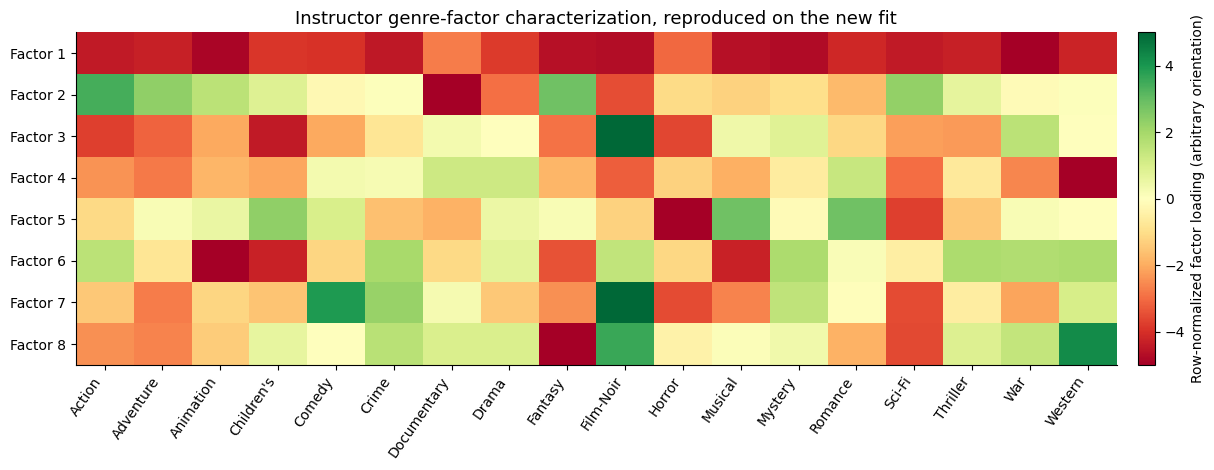

In [8]:
fig = genre_chart()
display(fig)
plt.close(fig)

### 9. Examine timestamp behavior

MovieLens documentation defines timestamps as rating-entry times. The following EDA uses all data for description only. No future rating is added to predictive training because it appears in this chart.

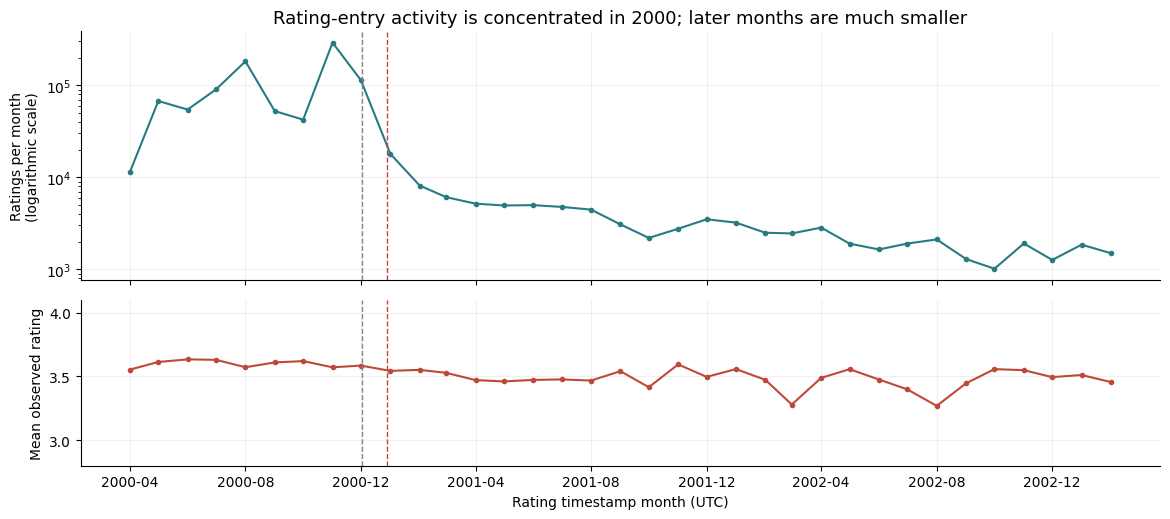

,month,ratings,users,mean_rating
7,2000-11,290793,2357,3.5717
4,2000-08,182109,1310,3.5722
8,2000-12,113487,1241,3.5850
3,2000-07,90334,778,3.6301
1,2000-05,67437,486,3.6134


In [9]:
fig = time_chart()
display(fig)
plt.close(fig)
display(pd.read_csv(ROOT / 'results/monthly_activity.csv').sort_values('ratings', ascending=False).head(5))

Rating volume is concentrated in 2000, with smaller later cohorts. Monthly mean ratings describe the observed sample and can change with user and movie composition. They do not show a causal shift in taste.

,Adjacent pairs,Same-second pairs,Same second (%),Within 60 seconds (%)
0,994169,529046,53.2149,88.7156


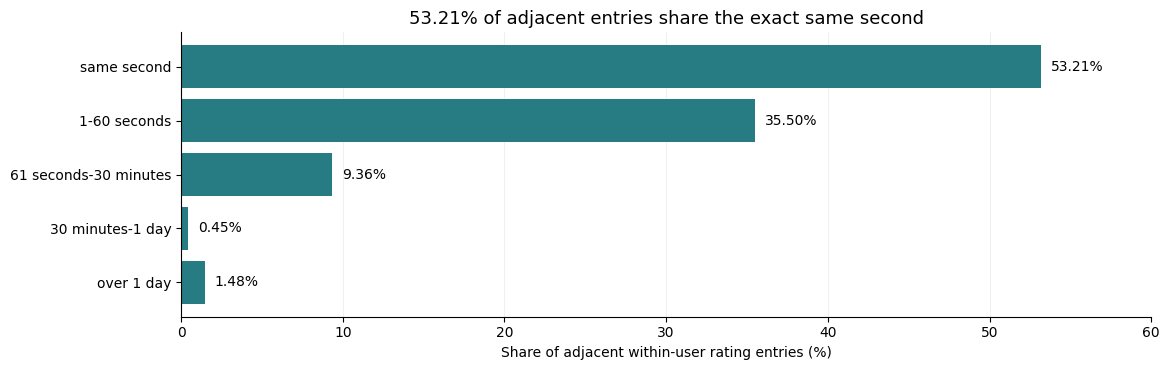

In [10]:
within_user = ratings.sort_values(['user', 'timestamp', 'movie']).groupby('user').timestamp.diff().dropna()
assert len(within_user) == len(ratings) - ratings.user.nunique()
display(pd.DataFrame([{'Adjacent pairs': len(within_user),
                      'Same-second pairs': int((within_user == 0).sum()),
                      'Same second (%)': 100 * (within_user == 0).mean(),
                      'Within 60 seconds (%)': 100 * (within_user <= 60).mean()}]))
fig = gap_chart()
display(fig)
plt.close(fig)

**53.21% share one second; 88.72% are within one minute.** A descriptive 30-minute gap produces 25,163 rating-entry batches (median 6 entries, 90th percentile 115). This is not a definition of a viewing session. For NextItNet, equal-second entries have no observed internal order. Movie-ID tie-breaking would be an imposed rule, not observed behavior.

中文：评分录入很集中；使用 timestamp 可以划分历史与未来，但不能据此断言用户真实看电影的先后顺序。

### 10. Check validation-to-test cohort change

Warm requires both user and movie in the fitted history. Validation uses the first 80% as its history; final test uses the first 90%. Cold ratings are retained and use a training-only fallback.

,split,ratings,users,mean_rating,rating_std,warm_rows,cold_rows,warm_fraction
0,train,800164,5400,3.5905,1.1203,800164,0,1.0000
1,validation,100024,1134,3.5914,1.1191,23844,76180,0.2384
2,test,100021,1209,3.5002,1.0855,95723,4298,0.9570


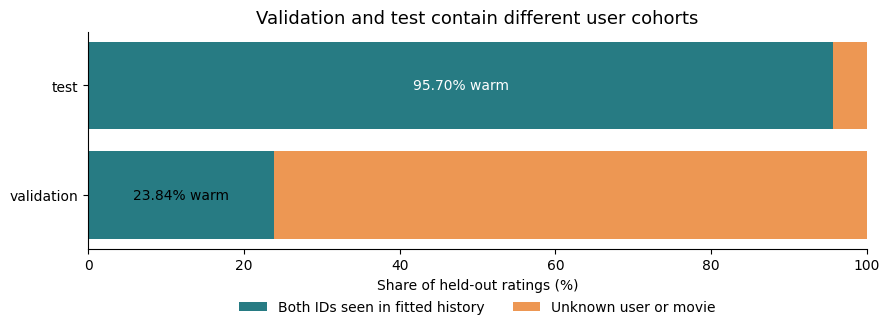

In [11]:
display(pd.read_csv(ROOT / 'results/temporal_population.csv'))
fig = population_chart()
display(fig)
plt.close(fig)

Only 23.84% of validation ratings are warm, compared with 95.70% of the final test. The low-rank/lambda=0 choice is driven by validation and transfers poorly to the final warm population. The factor-dot-product audit rules out a prediction alignment/calculation error; cohort mismatch is an interpretation, not a causal identification.

### 11. Compare static and timestamp ensembles

Static: CF prediction + 18 genres + release year + gender/age/occupation categories. Time: adds UTC hour/weekday, cyclic month, elapsed days, strict-past count and gap. Ridge alpha grid is {1, 100, 10,000}. Numerical elapsed/count/gap features are capped at meta-training ranges. No ZIP is used.

Random ensemble training uses teacher rank-8 OOF predictions. Forward training uses first-50%→50-65% and first-65%→65-80% predictions. The 80-90% validation chooses parameters, then joins the OOF calibration data for the final refit. None of the second-layer labels is paired with its own in-sample CF fitted value.

,protocol,model,rows,RMSE,MAE,OSR2
0,random_99_1,Training mean,10003,1.1237,0.9415,0.0000
3,random_99_1,softImpute,10003,0.9198,0.7106,0.3300
6,random_99_1,CF + metadata,10003,0.8990,0.7116,0.3599
9,random_99_1,CF + metadata + timestamp,10003,0.8940,0.7065,0.3671
12,global_time_80_10_10,Training mean,100021,1.0893,0.9025,0.0000
15,global_time_80_10_10,softImpute,100021,1.2246,0.9295,-0.2640
18,global_time_80_10_10,CF + metadata,100021,1.0303,0.8164,0.1053
21,global_time_80_10_10,CF + metadata + timestamp,100021,1.0001,0.7812,0.1571


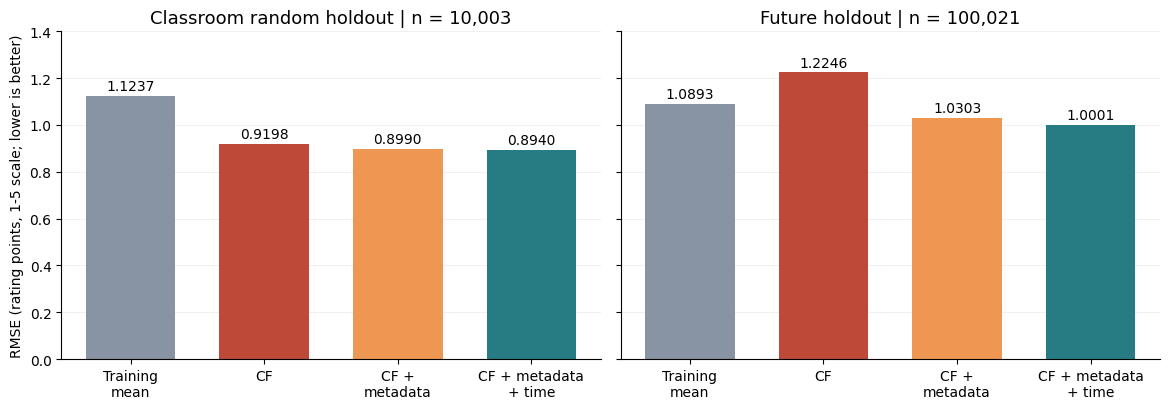

,rank,lambda,RMSE,warm
0,4,0,1.0365,23844
1,4,20,1.0428,23844
2,8,0,1.0558,23844
3,8,20,1.0434,23844
4,12,0,1.0669,23844
5,12,20,1.0431,23844


In [12]:
metrics = pd.read_csv(ROOT / 'results/model_metrics.csv')
overall = metrics[metrics.scope == 'all']
display(overall[['protocol', 'model', 'rows', 'RMSE', 'MAE', 'OSR2']])
fig = model_chart()
display(fig)
plt.close(fig)
display(pd.read_csv(ROOT / 'results/temporal_validation_grid.csv')[['rank','lambda','RMSE','warm']])

The future-test CF score is worse than the training mean (negative OSR²). The static and timestamp ensembles both improve over the training mean. We keep the poor CF result and do not reselect parameters after inspecting test errors. Random and future bars are separate tasks, not competing estimates of the same population.

### 12. Isolate the timestamp increment

A paired bootstrap resamples users 2,000 times. Each resample retains all rating events from sampled users and computes event-weighted RMSE. Positive difference means the time model has lower error than the static ensemble.

,Protocol,RMSE improvement,95% lower,95% upper,Users resampled
0,random,0.0050,0.0031,0.0069,3697
1,temporal,0.0302,0.0111,0.0504,1209


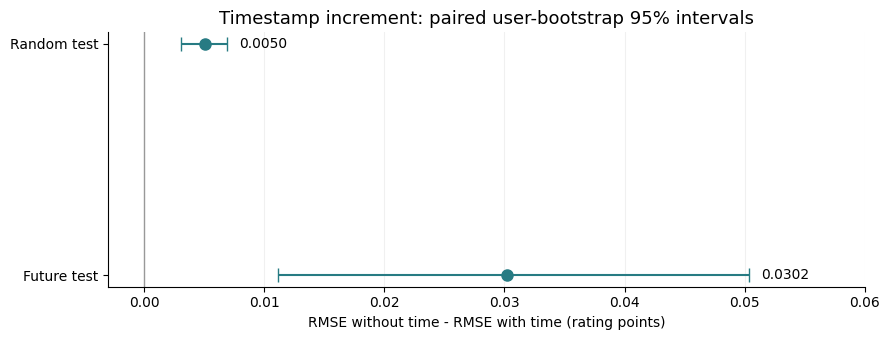

In [13]:
experiment = json.loads((ROOT / 'results/timestamp_experiment.json').read_text())
rows = []
for protocol, result in experiment['intervals'].items():
    d = result['CF + metadata']
    rows.append({'Protocol': protocol, 'RMSE improvement': d['improvement_RMSE'],
                 '95% lower': d['ci95'][0], '95% upper': d['ci95'][1],
                 'Users resampled': d['users']})
display(pd.DataFrame(rows))
fig = interval_chart()
display(fig)
plt.close(fig)

The timestamp increment is 0.0050 rating points (0.56%) in the random test and 0.0302 (2.93%) in the future test. Both user-bootstrap intervals are positive. These are conditional offline improvements; they do not establish higher viewing time, retention, or revenue.

### 13. Inspect future errors by month

The plot includes months with at least 200 held-out ratings; the complete CSV retains all months. This is a diagnostic readout of the fixed final experiment, not additional model selection.

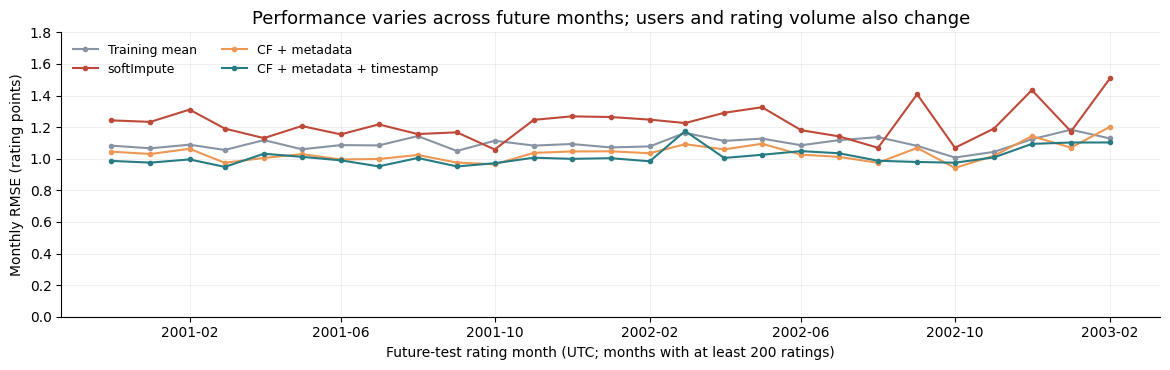

In [14]:
fig = forecast_chart()
display(fig)
plt.close(fig)

### 14. Independent integrity checks

The audit aligns every saved prediction with raw row IDs and labels, recomputes all 24 metric rows, verifies strict time boundaries, tests tied-time behavior, loads portable saved ensembles, and checks 400 distinct fresh fits. R separately checks latent-factor dot products and cold-start fallback values. Query rating labels do not enter feature generation.

In [15]:
from audit_analysis import audit
audited = audit(require_fresh=True, verbose=False)
display(pd.DataFrame({'Check': list(audited['checks']), 'Passed': list(audited['checks'].values())}))
assert audited['passed']
assert audited['max_independent_metric_error'] < 1e-10

,Check,Passed
0,random_disjoint_exhaustive,True
1,temporal_disjoint_exhaustive,True
2,temporal_strict_boundaries,True
3,exact_legacy_random_rows,True
4,all_20_instructor_cache_scores_match,True
5,random_99_1_features_ignore_query_labels,True
6,random_False_portable_prediction,True
7,random_True_portable_prediction,True
8,global_time_80_10_10_features_ignore_query_labels,True
9,temporal_False_portable_prediction,True


## Takeaways

For a course-aligned project, the rebuilt CF + regularized metadata/time ensemble is a concrete extension of the instructor method. Its timestamp increment is tested on the same holdout as its static counterpart. The temporal evaluation is the more relevant experiment if the deployment question concerns future ratings, but its validation/test cohorts differ substantially. Additional rolling validation would be a follow-up experiment with a new untouched future period, not a retroactive fix to this test.

中文：报告可以围绕“课堂方法复现 → 时间数据特点 → 规范的时间切分 → 时间特征消融 → 使用限制”展开。下一步若继续 NextItNet，需要单独设计 ranking 目标、候选电影集合和时间切分。不能把它的 Hit Rate / NDCG 与这里的 RMSE 混成一个优劣结论。

This companion satisfies the analytical parts of the project: visualization and a predictive model. The final D3 still needs a self-contained, double-spaced report, slides, sources and a truthful contribution appendix. None of these local artifacts has been submitted or published.

**Source index:** `sources/course_manifest.json`; detailed course split evidence: `Course_split_guide_CN.md`; original MovieLens definitions and terms: `sources/README_MovieLens.txt`; package/software versions: `results/python_environment.json` and `*_fit.csv`.